# Token-level inequality measures

This notebook computes per-token holder-concentration metrics for every
snapshot (one per calendar month from 2020-01 through 2025-12, plus D-1
and D+1 around a curated list of market events).

For each `(date, token_address)` pair the notebook produces, in one
DuckDB query:

- **holders**          — number of positive-balance holders
- **gini**, **hhi**    — classical inequality / concentration measures
- **top1/10/100**      — share held by the 1st / 10th / 100th largest holders
- **top1p/5p/10p**     — share held by the top 1% / 5% / 10% holders
- **nakamoto**         — minimum holders needed to control >= 50% of supply
- **supply**           — decimals-adjusted total supply

Results are streamed to `token_inequality_per_block.csv` (one row per
token per snapshot); the analysis section plots aggregate time-series
across tokens and surfaces the most/least concentrated tokens in the
latest snapshot.


In [ ]:
from __future__ import annotations

import os
import re
import pathlib
from dataclasses import dataclass
from typing import Dict, List, Optional

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from locations import Location


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
@dataclass
class Config:
    duckdb_threads: int = min(16, os.cpu_count() or 1)
    memory_limit: str = "8GB"
    temp_directory: Optional[str] = None  # e.g. "/scratch/$USER/duckdb_tmp" for big speedups

CONFIG = Config()

DATA_ROOT         = str(Location.PORTFOLIO_RECONSTRUCTION_DATA)
STATUS_CSV        = str(Location.TOKEN_STATUS_CSV)
DECIMALS_CACHE    = str(Location.TOKEN_DECIMALS_CACHE)
BLOCK_TO_DATE_CSV = str(Location.BLOCK_TO_DATE_CSV)

# Parquet schema columns
ADDR_COL = "address"
VAL_COL  = "value"
BLK_COL  = "block"

OUT_CSV = "token_inequality_per_block.csv"


# -----------------------------------------------------------------------------
# Small helpers
# -----------------------------------------------------------------------------
_id_re = re.compile(r"^[A-Za-z_][A-Za-z0-9_]*$")

def _safe_ident(name: str) -> str:
    if not _id_re.match(name):
        raise ValueError(f"Illegal identifier: {name!r}")
    return name

def _norm(x: object) -> str:
    return str(x).strip().lower()


In [2]:
def build_dates_list() -> List[str]:
    """Return a sorted list of YYYY-MM-DD snapshot dates.

    Includes the first day of every month from 2020-01 through 2025-12,
    plus D-1 and D+1 around each curated key event.
    """
    dates: List[str] = []
    start = pd.Timestamp("2020-01-01")
    end   = pd.Timestamp("2025-12-01")
    cur = start
    while cur <= end:
        dates.append(cur.strftime("%Y-%m-%d"))
        cur = cur + pd.offsets.MonthBegin(1)

    key_dates = [
        ("2023-03-11", "2023-03-12", "2023-03-13"),  # Signature Bank closure
        ("2023-04-11", "2023-04-12", "2023-04-13"),  # Ethereum Shapella
        ("2023-06-14", "2023-06-15", "2023-06-16"),  # BlackRock BTC ETF filing
        ("2023-10-15", "2023-10-16", "2023-10-17"),  # False ETF tweet spike
        ("2024-01-09", "2024-01-10", "2024-01-11"),  # BTC ETFs approved
        ("2024-03-12", "2024-03-13", "2024-03-14"),  # Ethereum Dencun
        ("2024-03-13", "2024-03-14", "2024-03-15"),  # BTC ATH
        ("2024-04-19", "2024-04-20", "2024-04-21"),  # Bitcoin halving
        ("2024-05-22", "2024-05-23", "2024-05-24"),  # ETH ETF approvals
        ("2024-07-22", "2024-07-23", "2024-07-24"),  # ETH ETFs begin trading
    ]

    neighbors = [d for (d_minus, _d, d_plus) in key_dates for d in (d_minus, d_plus)]

    all_dates = pd.to_datetime(pd.Series(dates + neighbors), errors="coerce").dropna().dt.normalize()
    all_dates = all_dates.drop_duplicates().sort_values()
    return all_dates.dt.strftime("%Y-%m-%d").tolist()


target_dates = build_dates_list()
print("Dates:", len(target_dates), "| first:", target_dates[0], "| last:", target_dates[-1])


Dates: 92 | first: 2020-01-01 | last: 2025-12-01


In [3]:
def resolve_blocks_for_dates(
    dates: List[str] | List[pd.Timestamp],
    block_to_date_csv: str,
) -> pd.DataFrame:
    """Look up the block number for each requested date.

    Returns a DataFrame with columns ['date', 'block'] where date is a
    YYYY-MM-DD string. Dates with no matching block in the mapping CSV
    are skipped with a warning.
    """
    if not dates:
        return pd.DataFrame(columns=["date", "block"])

    m = pd.read_csv(block_to_date_csv)

    block_col = next((c for c in ["block_number", "block"] if c in m.columns), None)
    if block_col is None:
        raise ValueError(f"No block column found in {block_to_date_csv}. Got {list(m.columns)}")

    date_col = next((c for c in ["date", "bound_date", "block_time_utc"] if c in m.columns), None)
    if date_col is None:
        raise ValueError(f"No date column found in {block_to_date_csv}. Got {list(m.columns)}")

    m[date_col] = pd.to_datetime(m[date_col], errors="coerce").dt.normalize()
    m = m.dropna(subset=[date_col, block_col])

    req = pd.to_datetime(pd.Series(dates), errors="coerce").dropna().dt.normalize()
    req = req.drop_duplicates().sort_values()

    rows: List[tuple[str, int]] = []
    for d in req:
        hit = m.loc[m[date_col] == d]
        if hit.empty:
            print(f"[warn] no block for date {d.date()} (skipping)")
            continue
        rows.append((d.strftime("%Y-%m-%d"), int(hit.iloc[0][block_col])))

    out = pd.DataFrame(rows, columns=["date", "block"]).drop_duplicates().sort_values(["date", "block"])
    return out


date_block_df = resolve_blocks_for_dates(target_dates, BLOCK_TO_DATE_CSV)
print("Resolved pairs:", len(date_block_df))
display(date_block_df.head(10))


Resolved pairs: 92


,date,block
0,2020-01-01,9193266
1,2020-02-01,9393154
2,2020-03-01,9581792
3,2020-04-01,9782602
4,2020-05-01,9976964
5,2020-06-01,10176690
6,2020-07-01,10370274
7,2020-08-01,10570485
8,2020-09-01,10771925
9,2020-10-01,10966874


In [4]:
import json

def load_decimals_cache(path: str) -> Dict[str, int]:
    """Load {token_address: decimals} from a JSON cache file, if present."""
    if not path or not os.path.exists(path):
        return {}
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    out: Dict[str, int] = {}
    for k, v in data.items():
        try:
            out[str(k).strip().lower()] = int(v)
        except Exception:
            pass
    return out


decimals_map = load_decimals_cache(DECIMALS_CACHE)
print("Decimals loaded:", len(decimals_map))


Decimals loaded: 5081


In [7]:
def compute_metrics_for_block_duckdb(
    max_block: int,
    date_str: str,
    *,
    data_root: str,
    status_csv: str,
    decimals_map: Dict[str, int],
    addr_col: str = "address",
    val_col: str = "value",
    blk_col: str = "block",
    parquet_glob: Optional[str] = None,
) -> pd.DataFrame:
    """Compute per-token concentration metrics at `max_block` in one DuckDB query.

    Output columns:
        date, block, token_address, token_name, holders, gini, hhi,
        top1, top10, top100, top1p, top5p, top10p, nakamoto, supply
    """
    addr_col = _safe_ident(addr_col)
    val_col  = _safe_ident(val_col)
    blk_col  = _safe_ident(blk_col)

    if parquet_glob is None:
        parquet_glob = f"{data_root}/token_address=*/**/*.parquet"

    # Build a small decimals table (token_address, decimals).
    if decimals_map:
        dec_df = pd.DataFrame(
            {"token_address": list(decimals_map.keys()), "decimals": list(decimals_map.values())}
        )
    else:
        dec_df = pd.DataFrame({"token_address": [], "decimals": []})

    con = duckdb.connect()
    try:
        con.execute(f"PRAGMA threads={int(CONFIG.duckdb_threads)};")
        con.execute(f"PRAGMA memory_limit='{CONFIG.memory_limit}';")
        if CONFIG.temp_directory:
            os.makedirs(CONFIG.temp_directory, exist_ok=True)
            con.execute(f"PRAGMA temp_directory='{CONFIG.temp_directory}';")

        # Whitelist + labels inside DuckDB (fast, no pandas filtering).
        con.execute(f"""
            CREATE TEMP TABLE wl AS
            SELECT
                lower(trim(contract_address)) AS token_address,
                CASE
                  WHEN coalesce(nullif(trim(symbol), ''), '') != '' THEN trim(symbol)
                  ELSE trim(name)
                END AS token_name
            FROM read_csv_auto('{status_csv}', all_varchar=true)
            WHERE lower(trim(local_status)) = 'pass'
              AND contract_address IS NOT NULL
              AND length(trim(contract_address)) = 42
              AND left(lower(trim(contract_address)), 2) = '0x';
        """)

        con.register("dec_df", dec_df)
        con.execute("""
            CREATE TEMP TABLE dec AS
            SELECT lower(token_address) AS token_address, CAST(decimals AS INTEGER) AS decimals
            FROM dec_df;
        """)

        sql = f"""
        WITH raw AS (
            SELECT
                lower(token_address) AS token_address,
                lower({addr_col})    AS address,
                TRY_CAST({val_col} AS DOUBLE) AS v,
                TRY_CAST({blk_col} AS BIGINT) AS blk
            FROM parquet_scan('{parquet_glob}', hive_partitioning=1, union_by_name=1)
            WHERE TRY_CAST({val_col} AS DOUBLE) IS NOT NULL
              AND TRY_CAST({blk_col} AS BIGINT) IS NOT NULL
              AND TRY_CAST({blk_col} AS BIGINT) <= {int(max_block)}
        ),
        raw_w AS (
            SELECT r.*
            FROM raw r
            JOIN wl USING (token_address)
        ),
        -- sum per address, skip addresses where SUM < 0
        bal AS (
            SELECT
                token_address,
                address,
                SUM(v) AS balance
            FROM raw_w
            GROUP BY token_address, address
            HAVING SUM(v) >= 0
        ),
        -- only positive holders for concentration stats
        holders AS (
            SELECT token_address, address, balance
            FROM bal
            WHERE balance > 0
        ),
        stats AS (
            SELECT
                token_address,
                COUNT(*)::BIGINT AS n_holders,
                SUM(balance)     AS supply_raw
            FROM holders
            GROUP BY token_address
        ),
        ranked AS (
            SELECT
                h.token_address,
                h.address,
                h.balance,
                s.n_holders,
                s.supply_raw,
                ROW_NUMBER() OVER (PARTITION BY h.token_address ORDER BY h.balance DESC) AS rn_desc,
                ROW_NUMBER() OVER (PARTITION BY h.token_address ORDER BY h.balance ASC)  AS rn_asc,
                SUM(h.balance) OVER (
                    PARTITION BY h.token_address
                    ORDER BY h.balance DESC
                    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                ) / s.supply_raw AS cum_share_desc
            FROM holders h
            JOIN stats s USING (token_address)
        ),
        metrics AS (
            SELECT
                token_address,
                MAX(n_holders) AS holders,
                MAX(supply_raw) AS supply_raw,

                -- HHI
                SUM( (balance / supply_raw) * (balance / supply_raw) ) AS hhi,

                -- Top-K shares
                SUM(CASE WHEN rn_desc <= 1   THEN balance ELSE 0 END) / MAX(supply_raw) AS top1,
                SUM(CASE WHEN rn_desc <= 10  THEN balance ELSE 0 END) / MAX(supply_raw) AS top10,
                SUM(CASE WHEN rn_desc <= 100 THEN balance ELSE 0 END) / MAX(supply_raw) AS top100,

                -- Top-% shares (k = ceil(pct * n_holders))
                SUM(CASE WHEN rn_desc <= CEIL(0.01 * n_holders) THEN balance ELSE 0 END) / MAX(supply_raw) AS top1p,
                SUM(CASE WHEN rn_desc <= CEIL(0.05 * n_holders) THEN balance ELSE 0 END) / MAX(supply_raw) AS top5p,
                SUM(CASE WHEN rn_desc <= CEIL(0.10 * n_holders) THEN balance ELSE 0 END) / MAX(supply_raw) AS top10p,

                -- Nakamoto(50%)
                MIN(CASE WHEN cum_share_desc >= 0.5 THEN rn_desc ELSE NULL END) AS nakamoto,

                -- Gini (ascending ranks)
                (
                    (2.0 * SUM(rn_asc * balance) / (MAX(n_holders) * MAX(supply_raw)))
                    - (MAX(n_holders) + 1.0) / MAX(n_holders)
                ) AS gini
            FROM ranked
            GROUP BY token_address
        )
        SELECT
            '{date_str}' AS date,
            {int(max_block)} AS block,
            m.token_address AS token_address,
            wl.token_name   AS token_name,
            m.holders       AS holders,
            m.gini          AS gini,
            m.hhi           AS hhi,
            m.top1          AS top1,
            m.top10         AS top10,
            m.top100        AS top100,
            m.top1p         AS top1p,
            m.top5p         AS top5p,
            m.top10p        AS top10p,
            m.nakamoto      AS nakamoto,
            (m.supply_raw / POWER(10.0, COALESCE(dec.decimals, 18))) AS supply
        FROM metrics m
        JOIN wl USING (token_address)
        LEFT JOIN dec USING (token_address)
        WHERE m.holders > 1
        ;
        """

        return con.execute(sql).df()

    finally:
        con.close()


In [8]:
def compute_metrics_for_all_snapshots_to_csv(
    date_block_df: pd.DataFrame,
    *,
    out_csv: str,
    data_root: str,
    status_csv: str,
    decimals_map: Dict[str, int],
) -> None:
    """Run compute_metrics_for_block_duckdb over every (date, block) pair.

    Writes results incrementally to `out_csv` (one pass per snapshot), so
    an interrupted run can be resumed by deleting the partial file and
    restarting from the next block.
    """
    if date_block_df.empty:
        print("[warn] No (date, block) pairs. Nothing to do.")
        return

    date_block_df = date_block_df.drop_duplicates(subset=["date", "block"]).sort_values(["date", "block"])

    if os.path.exists(out_csv):
        print(f"[info] Removing existing {out_csv}")
        os.remove(out_csv)

    header_written = False

    for row in date_block_df.itertuples(index=False):
        date_str = str(row.date)
        blk = int(row.block)

        print(f"\n=== {date_str} | block {blk} ===")
        df_b = compute_metrics_for_block_duckdb(
            max_block=blk,
            date_str=date_str,
            data_root=data_root,
            status_csv=status_csv,
            decimals_map=decimals_map,
            addr_col=ADDR_COL,
            val_col=VAL_COL,
            blk_col=BLK_COL,
        )

        if df_b.empty:
            print("  -> no rows (maybe no whitelist tokens found in shards?)")
            continue

        desired = [
            "date","block","token_address","token_name","holders",
            "gini","hhi","top1","top10","top100","top1p","top5p","top10p",
            "nakamoto","supply"
        ]
        df_b = df_b[desired]

        mode = "a" if header_written else "w"
        df_b.to_csv(out_csv, mode=mode, index=False, header=not header_written)
        header_written = True

        del df_b

    print(f"\nDone. Wrote: {out_csv}")


compute_metrics_for_all_snapshots_to_csv(
    date_block_df=date_block_df,
    out_csv=OUT_CSV,
    data_root=DATA_ROOT,
    status_csv=STATUS_CSV,
    decimals_map=decimals_map,
)



=== 2020-01-01 | block 9193266 ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== 2020-02-01 | block 9393154 ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== 2020-03-01 | block 9581792 ===


...


=== 2025-11-01 | block 23700767 ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== 2025-12-01 | block 23914921 ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Done. Wrote: token_inequality_per_block___2.csv


Rows: 179869 | tokens: 4504 | dates: 92


,date,block,token_address,token_name,holders,gini,hhi,top1,top10,top100,top1p,top5p,top10p,nakamoto,supply
0,2020-01-01,9193266,0xd4fa1460f537bb9085d22c7bccb5dd450ef28e3a,ppt,26581,0.959300,0.055586,0.206594,0.440858,0.673583,0.762248,0.893322,0.940069,18,5.325225e+07
1,2020-01-01,9193266,0x4824a7b64e3966b0133f4f4ffb1b9d6beb75fff7,tct,19661,0.999433,0.182068,0.300000,0.950250,0.992018,0.997113,0.999813,0.999905,2,1.000000e+09
2,2020-01-01,9193266,0x6b175474e89094c44da98b954eedeac495271d0f,dai,13226,0.986536,0.022432,0.059190,0.404001,0.820700,0.856549,0.973919,0.991825,15,4.223652e+07
3,2020-01-01,9193266,0x3506424f91fd33084466f402d5d97f05f8e3b4af,chz,7041,0.984633,0.382920,0.576587,0.883188,0.949626,0.943599,0.969100,0.979154,1,8.888889e+09
4,2020-01-01,9193266,0xdac17f958d2ee523a2206206994597c13d831ec7,usdt,691382,0.992335,0.014928,0.075298,0.284729,0.540569,0.955227,0.980139,0.988756,76,2.300001e+09


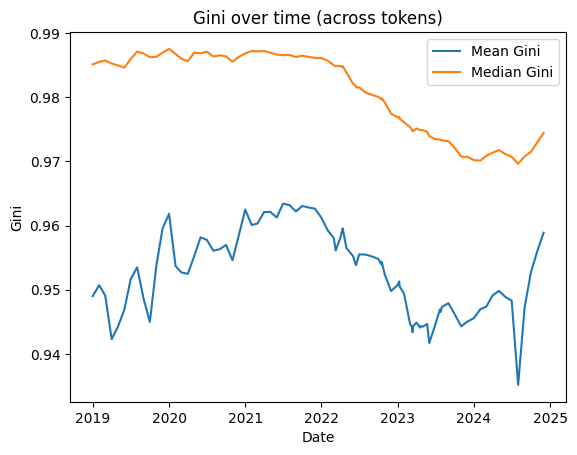

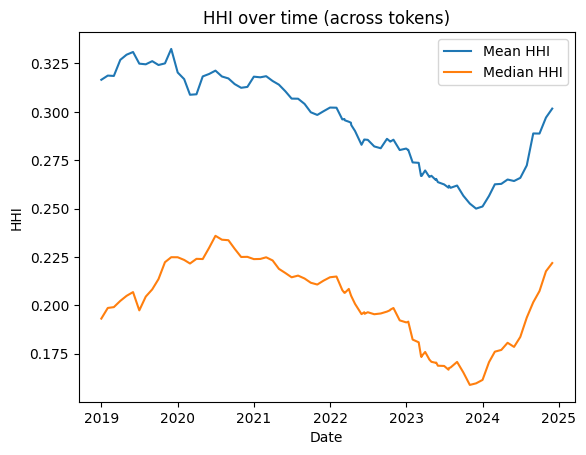

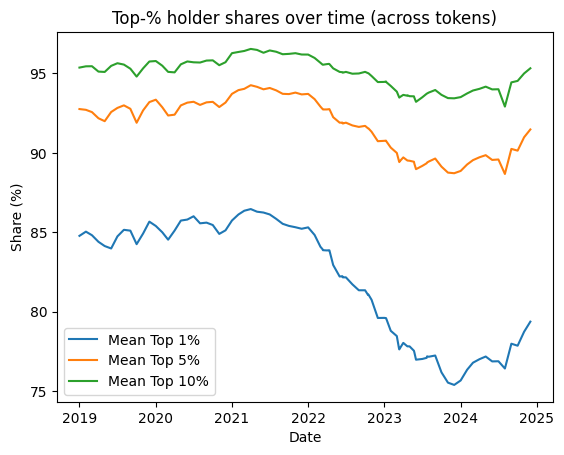

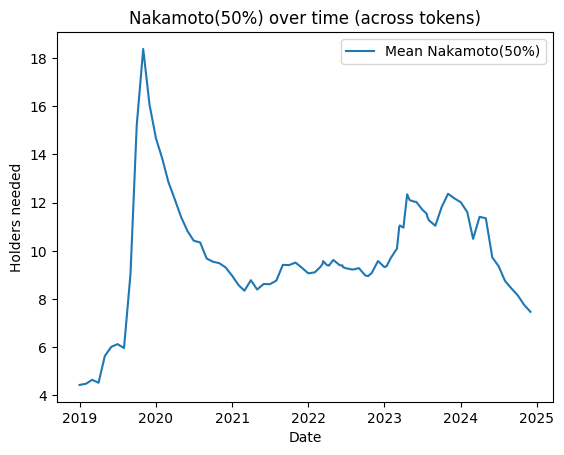

Latest snapshot: 2025-12-01 | rows: 4504


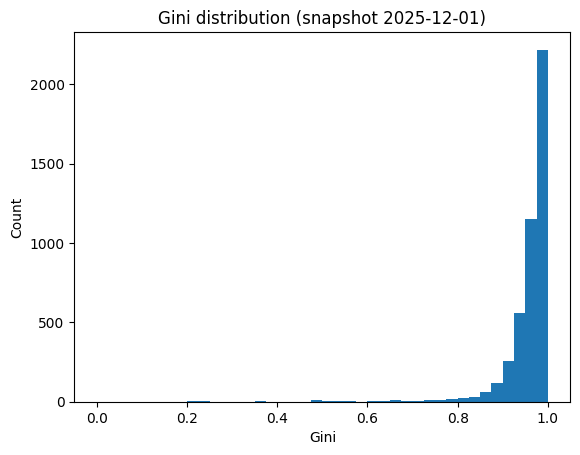

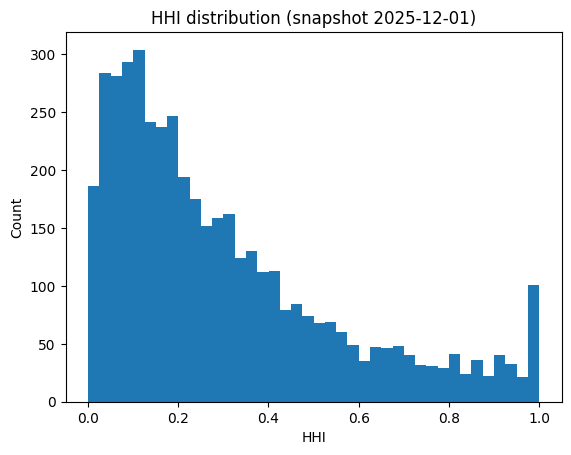

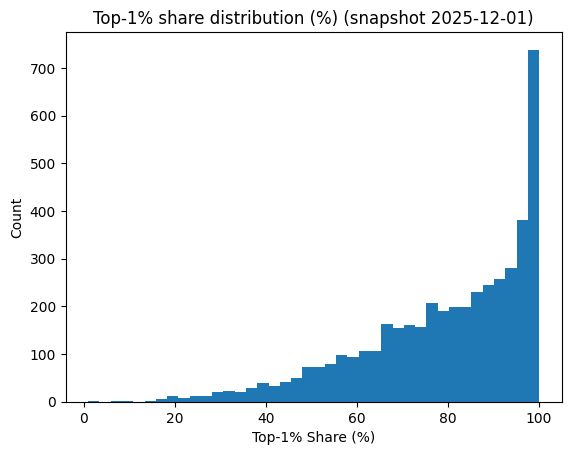


Top-10 most concentrated (by Gini):


,token_address,token_name,holders,gini,hhi,top1,top1p,top5p,top10p,nakamoto,top1_pct,top1p_pct,top5p_pct,top10p_pct
177720,0xc139190f447e929f090edeb554d95abb8b18ac1c,usdtb,293177,0.999990,0.694694,0.831242,1.000000,1.000000,1.000000,1,83.12,100.00,100.00,100.00
178543,0x08d32b0da63e2c3bcf8019c9c5d849d7a9d791e6,dcn,55426,0.999982,0.998406,0.999202,1.000000,1.000000,1.000000,1,99.92,100.00,100.00,100.00
175729,0x667102bd3413bfeaa3dffb48fa8288819e480a88,tkx,54262,0.999951,0.393110,0.553907,1.000000,1.000000,1.000000,1,55.39,100.00,100.00,100.00
178435,0x525a8f6f3ba4752868cde25164382bfbae3990e1,nym,17384,0.999942,1.000000,1.000000,1.000000,1.000000,1.000000,1,100.00,100.00,100.00,100.00
178442,0xa6089dbfed19d1bcd43146bbdca2b8f9d9f84a9a,ugold,20320,0.999926,0.979999,0.989939,0.999972,0.999976,0.999978,1,98.99,100.00,100.00,100.00
175965,0x1a4b46696b2bb4794eb3d4c26f1c55f9170fa4c5,bit,17804,0.999922,0.977471,0.988615,0.999872,0.999949,0.999972,1,98.86,99.99,99.99,100.00
175950,0x630d98424efe0ea27fb1b3ab7741907dffeaad78,peak,11054,0.999910,1.000000,1.000000,1.000000,1.000000,1.000000,1,100.00,100.00,100.00,100.00
175825,0xf091867ec603a6628ed83d274e835539d82e9cc8,zeta,79306,0.999896,0.524358,0.714286,0.999606,0.999929,0.999949,1,71.43,99.96,99.99,99.99
175910,0x8d96b4ab6c741a4c8679ae323a100d74f085ba8f,bzr,10119,0.999869,0.970841,0.985298,0.999980,0.999982,0.999984,1,98.53,100.00,100.00,100.00
179595,0xa37db5456b5938aa50b33575ae2eb8048ca5959b,dop2,18972,0.999858,0.423396,0.492138,0.999877,0.999992,0.999995,2,49.21,99.99,100.00,100.00



Top-10 least concentrated (by Gini):


,token_address,token_name,holders,gini,hhi,top1,top1p,top5p,top10p,nakamoto,top1_pct,top1p_pct,top5p_pct,top10p_pct
178795,0xa20f77b7ad5a88badc48800c56507b7274c06fdc,cher,100,0.000198,0.010000,0.010198,0.010198,0.050190,0.100180,50,1.02,1.02,5.02,10.02
178729,0x499568c250ab2a42292261d6121525d70691894b,krw,2,0.118166,0.527927,0.618166,0.618166,0.618166,0.618166,1,61.82,61.82,61.82,61.82
178474,0xbc0899e527007f1b8ced694508fcb7a2b9a46f53,bskt,11061,0.208463,0.007104,0.062752,0.185745,0.245350,0.285325,4077,6.28,18.57,24.54,28.53
178783,0xc08cd26474722ce93f4d0c34d16201461c10aa8c,carv,14,0.208524,0.084945,0.094943,0.094943,0.094943,0.189887,6,9.49,9.49,9.49,18.99
178786,0x845e2e8b42dced7dedcdba9bde32c9e338224f97,satoz,3,0.226667,0.391200,0.500000,0.500000,0.500000,0.500000,1,50.00,50.00,50.00,50.00
179019,0x6403af1267cacc0714c1bd916b12f80e179c0558,hai,3,0.231111,0.397689,0.533333,0.533333,0.533333,0.533333,1,53.33,53.33,53.33,53.33
178873,0x25c31b1f93f846c7c8debfd05898f162740a4581,wander,2,0.367914,0.770722,0.867914,0.867914,0.867914,0.867914,1,86.79,86.79,86.79,86.79
179655,0x9b61879e91a0b1322f3d61c23aaf936231882096,br,4,0.375000,0.437500,0.625000,0.625000,0.625000,0.625000,1,62.50,62.50,62.50,62.50
178798,0xbeef01060047522408756e0000a90ce195a70000,aptr,3,0.381485,0.508921,0.574976,0.574976,0.574976,0.574976,1,57.50,57.50,57.50,57.50
178450,0x1903be033d3e436dd79a8cf9030675bcf97ab589,bjk,5,0.409646,0.315406,0.379310,0.379310,0.379310,0.379310,2,37.93,37.93,37.93,37.93


In [9]:
df = pd.read_csv(OUT_CSV, dtype={"token_address": str})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Rows:", len(df), "| tokens:", df["token_address"].nunique(), "| dates:", df["date"].nunique())
display(df.head(5))


# -----------------------------------------------------------------------------
# Aggregate per date across tokens
# -----------------------------------------------------------------------------
agg = df.groupby("date", as_index=False).agg(
    tokens=("token_address", "nunique"),
    mean_gini=("gini", "mean"),
    median_gini=("gini", "median"),
    mean_hhi=("hhi", "mean"),
    median_hhi=("hhi", "median"),
    mean_top1p=("top1p", "mean"),
    mean_top5p=("top5p", "mean"),
    mean_top10p=("top10p", "mean"),
    mean_nakamoto=("nakamoto", "mean"),
)

# Gini time-series
plt.figure()
plt.plot(agg["date"], agg["mean_gini"], label="Mean Gini")
plt.plot(agg["date"], agg["median_gini"], label="Median Gini")
plt.title("Gini over time (across tokens)")
plt.xlabel("Date")
plt.ylabel("Gini")
plt.legend(loc="best")
plt.show()

# HHI time-series
plt.figure()
plt.plot(agg["date"], agg["mean_hhi"], label="Mean HHI")
plt.plot(agg["date"], agg["median_hhi"], label="Median HHI")
plt.title("HHI over time (across tokens)")
plt.xlabel("Date")
plt.ylabel("HHI")
plt.legend(loc="best")
plt.show()

# Top-% shares time-series
plt.figure()
plt.plot(agg["date"], agg["mean_top1p"] * 100, label="Mean Top 1%")
plt.plot(agg["date"], agg["mean_top5p"] * 100, label="Mean Top 5%")
plt.plot(agg["date"], agg["mean_top10p"] * 100, label="Mean Top 10%")
plt.title("Top-% holder shares over time (across tokens)")
plt.xlabel("Date")
plt.ylabel("Share (%)")
plt.legend(loc="best")
plt.show()

# Nakamoto time-series
plt.figure()
plt.plot(agg["date"], agg["mean_nakamoto"], label="Mean Nakamoto(50%)")
plt.title("Nakamoto(50%) over time (across tokens)")
plt.xlabel("Date")
plt.ylabel("Holders needed")
plt.legend(loc="best")
plt.show()


# -----------------------------------------------------------------------------
# Latest snapshot: distributions and most/least concentrated tokens
# -----------------------------------------------------------------------------
latest_date = df["date"].dropna().max()
snap = df[df["date"] == latest_date].copy()
print("Latest snapshot:", latest_date.date(), "| rows:", len(snap))

plt.figure()
snap["gini"].dropna().plot(kind="hist", bins=40)
plt.title(f"Gini distribution (snapshot {latest_date.date()})")
plt.xlabel("Gini")
plt.ylabel("Count")
plt.show()

plt.figure()
snap["hhi"].dropna().plot(kind="hist", bins=40)
plt.title(f"HHI distribution (snapshot {latest_date.date()})")
plt.xlabel("HHI")
plt.ylabel("Count")
plt.show()

plt.figure()
(snap["top1p"].dropna() * 100).plot(kind="hist", bins=40)
plt.title(f"Top-1% share distribution (%) (snapshot {latest_date.date()})")
plt.xlabel("Top-1% Share (%)")
plt.ylabel("Count")
plt.show()

top10 = snap.nlargest(10, "gini")[["token_address","token_name","holders","gini","hhi","top1","top1p","top5p","top10p","nakamoto"]]
bot10 = snap.nsmallest(10, "gini")[["token_address","token_name","holders","gini","hhi","top1","top1p","top5p","top10p","nakamoto"]]

print("\nTop-10 most concentrated (by Gini):")
display(top10.assign(
    top1_pct=(top10["top1"]*100).round(2),
    top1p_pct=(top10["top1p"]*100).round(2),
    top5p_pct=(top10["top5p"]*100).round(2),
    top10p_pct=(top10["top10p"]*100).round(2),
))

print("\nTop-10 least concentrated (by Gini):")
display(bot10.assign(
    top1_pct=(bot10["top1"]*100).round(2),
    top1p_pct=(bot10["top1p"]*100).round(2),
    top5p_pct=(bot10["top5p"]*100).round(2),
    top10p_pct=(bot10["top10p"]*100).round(2),
))
